In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
from datasets import load_dataset

dataset = load_dataset("ylecun/mnist")

/Users/vallurileelasaikrishna/mnist/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [5]:
X_train = np.array(dataset["train"]["image"]).reshape(-1, 784) / 255
y_train = list(dataset["train"]["label"])
X_test = np.array(dataset["test"]["image"]).reshape(-1, 784) / 255
y_test = list(dataset["test"]["label"])

6

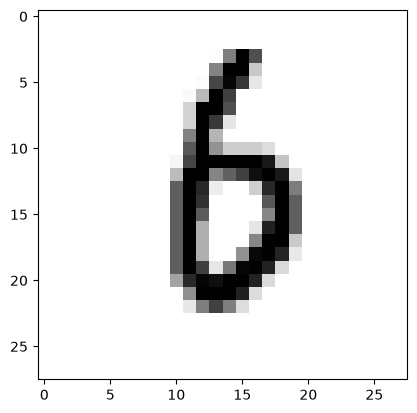

In [6]:
plt.imshow(X_train[3454].reshape(28,28), cmap="grey_r")
y_train[3454]

In [7]:
X_train[3454]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [8]:
X_train.shape

(60000, 784)

### Parameters

- one input layer:  
    input = X(= A0)(784,60000)  

- first hidden layers:  
    W1(10,784)  
    b1(10,1)  
    Z1(10,60000) = W1*A0 + b1  
    A1 = Relu(Z1)  

- second hidden layer:  
    W2(10,10)  
    b2(10,1)  
    Z2(10,60000) = W2*A1 + b2  
    A2 = Relu(Z2)  

- final output layer:    
    W3(10,10)  
    b3(10,1)  
    Z3(10,60000) = W3*A2 + b3  
    A3 = softmax(Z3)  
    output = A3  

In [9]:
def Relu(z):
    return np.maximum(0, z)

In [10]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [11]:
def init_para(X_train):
    A0 = X_train.T

    np.random.seed(67)
    W1 = np.random.randn(10, 784)
    b1 = np.random.randn(10, 1)

    W2 = np.random.randn(10, 10)
    b2 = np.random.randn(10, 1)

    W3 = np.random.randn(10, 10)
    b3 = np.random.randn(10, 1)

    return A0, W1, b1, W2, b2, W3, b3

In [12]:
def forward_prop(A0, W1, b1, W2, b2, W3, b3):
    Z1 = W1 @ A0 + b1
    A1 = Relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = Relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [13]:
def deriv_Relu(z):
    return (z>0).astype(float)

In [14]:
def loss_function(y, y_pred):
    return -np.sum(y * (np.log(y_pred)))

In [15]:
def one_hot(y):
    y = np.array(y)
    m = y.size  
    one_hot_y = np.zeros((10, m))
    one_hot_y[y, np.arange(m)] = 1
    
    return one_hot_y

In [16]:
def back_prop(A0, Z1, A1, W2, Z2, A2, W3, A3, y_train):
    m = X_train.shape[0]
    y = one_hot(y_train)

    dZ3 = A3 - y
    dW3 = dZ3 @ A2.T / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    dZ2 = W3.T @ dZ3 * deriv_Relu(Z2)
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = W2.T @ dZ2 * deriv_Relu(Z1)
    dW1 = dZ1 @ A0.T / m 
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m
    
    return dW1, db1, dW2, db2, dW3, db3

In [17]:
def update_para(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 -= alpha * dW1
    W2 -= alpha * dW2
    W3 -= alpha * dW3
    b1 -= alpha * db1
    b2 -= alpha * db2
    b3 -= alpha * db3

    return W1, W2, W3, b1, b2, b3

In [22]:
def gradient_descent(X_train, y_train, iterations, tol, alpha, init = False, para = []):
    if not init:
        A0, W1, b1, W2, b2, W3, b3 = init_para(X_train)
    else:
        A0, W1, b1, W2, b2, W3, b3 = para
    for j in range(iterations + 1):
        Z1, A1, Z2, A2, Z3, A3 = forward_prop(A0, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = back_prop(A0, Z1, A1, W2, Z2, A2, W3, A3, y_train)
        W1, W2, W3, b1, b2, b3 = update_para(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
        if not (j % 100):
            print("iteration :", j)
            print("accuracy :", np.mean(np.argmax(A3, axis=0) == np.array(y_train).flatten()) * 100)
    return W1, b1, W2, b2, W3, b3

In [23]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, y_train, 5000, 0, 0.1)

iteration : 0
accuracy : 9.478333333333333
iteration : 100
accuracy : 10.459999999999999
iteration : 200
accuracy : 13.84
iteration : 300
accuracy : 15.321666666666667
iteration : 400
accuracy : 22.428333333333335
iteration : 500
accuracy : 28.636666666666667
iteration : 600
accuracy : 30.471666666666668
iteration : 700
accuracy : 32.288333333333334
iteration : 800
accuracy : 34.026666666666664
iteration : 900
accuracy : 35.556666666666665
iteration : 1000
accuracy : 36.85666666666666
iteration : 1100
accuracy : 38.09
iteration : 1200
accuracy : 37.82666666666666
iteration : 1300
accuracy : 38.845
iteration : 1400
accuracy : 39.63166666666667
iteration : 1500
accuracy : 40.415
iteration : 1600
accuracy : 41.248333333333335
iteration : 1700
accuracy : 41.943333333333335
iteration : 1800
accuracy : 42.593333333333334
iteration : 1900
accuracy : 43.266666666666666
iteration : 2000
accuracy : 44.056666666666665
iteration : 2100
accuracy : 44.925
iteration : 2200
accuracy : 45.875
iteration

In [24]:
nW1, nb1, nW2, nb2, nW3, nb3 = gradient_descent(X_train, y_train, 5000, 0, 0.1, True, [X_train.T, W1, b1, W2, b2, W3, b3])

iteration : 0
accuracy : 67.51333333333334
iteration : 100
accuracy : 68.55166666666666
iteration : 200
accuracy : 69.785
iteration : 300
accuracy : 70.46833333333333
iteration : 400
accuracy : 71.12166666666667
iteration : 500
accuracy : 70.88833333333334
iteration : 600
accuracy : 71.49333333333333
iteration : 700
accuracy : 71.44833333333334
iteration : 800
accuracy : 72.13666666666667
iteration : 900
accuracy : 72.50666666666666
iteration : 1000
accuracy : 73.03333333333333
iteration : 1100
accuracy : 73.26
iteration : 1200
accuracy : 73.58166666666666
iteration : 1300
accuracy : 73.92666666666666
iteration : 1400
accuracy : 74.20833333333333
iteration : 1500
accuracy : 74.41166666666666
iteration : 1600
accuracy : 74.69
iteration : 1700
accuracy : 74.97
iteration : 1800
accuracy : 75.315
iteration : 1900
accuracy : 74.285
iteration : 2000
accuracy : 75.43166666666666
iteration : 2100
accuracy : 75.78
iteration : 2200
accuracy : 76.095
iteration : 2300
accuracy : 76.15333333333332


In [28]:
n1W1, n1b1, n1W2, n1b2, n1W3, n1b3 = gradient_descent(X_train, y_train, 5000, 0, 0.05, True, [X_train.T, nW1, nb1, nW2, nb2, nW3, nb3])

iteration : 0
accuracy : 79.56666666666666
iteration : 100
accuracy : 79.56833333333333
iteration : 200
accuracy : 79.605
iteration : 300
accuracy : 79.77333333333333
iteration : 400
accuracy : 80.02333333333334
iteration : 500
accuracy : 80.25333333333333
iteration : 600
accuracy : 80.50500000000001
iteration : 700
accuracy : 80.635
iteration : 800
accuracy : 80.78166666666667
iteration : 900
accuracy : 80.90166666666667
iteration : 1000
accuracy : 81.00166666666667
iteration : 1100
accuracy : 81.10833333333333
iteration : 1200
accuracy : 81.20166666666667
iteration : 1300
accuracy : 81.265
iteration : 1400
accuracy : 81.32333333333334
iteration : 1500
accuracy : 81.42833333333334
iteration : 1600
accuracy : 81.52166666666668
iteration : 1700
accuracy : 81.58666666666666
iteration : 1800
accuracy : 81.61166666666666
iteration : 1900
accuracy : 81.66499999999999
iteration : 2000
accuracy : 81.73333333333333
iteration : 2100
accuracy : 81.77666666666667
iteration : 2200
accuracy : 81.80

In [37]:
n2W1, n2b1, n2W2, n2b2, n2W3, n2b3 = gradient_descent(X_train, y_train, 5000, 0, 0.05, True, [X_train.T, n1W1, n1b1, n1W2, n1b2, n1W3, n1b3])

iteration : 0
accuracy : 82.48833333333333
iteration : 100
accuracy : 82.54833333333333
iteration : 200
accuracy : 82.56166666666667
iteration : 300
accuracy : 82.55833333333334
iteration : 400
accuracy : 82.61666666666667
iteration : 500
accuracy : 82.60333333333332
iteration : 600
accuracy : 82.63166666666667
iteration : 700
accuracy : 82.62833333333333
iteration : 800
accuracy : 82.66166666666666
iteration : 900
accuracy : 82.67999999999999
iteration : 1000
accuracy : 82.705
iteration : 1100
accuracy : 82.69833333333332
iteration : 1200
accuracy : 82.72333333333334
iteration : 1300
accuracy : 82.73
iteration : 1400
accuracy : 82.785
iteration : 1500
accuracy : 82.77333333333333
iteration : 1600
accuracy : 82.78166666666667
iteration : 1700
accuracy : 82.81166666666667
iteration : 1800
accuracy : 82.80999999999999
iteration : 1900
accuracy : 82.82000000000001
iteration : 2000
accuracy : 82.83166666666666
iteration : 2100
accuracy : 82.84666666666666
iteration : 2200
accuracy : 82.851

In [44]:
n3W1, n3b1, n3W2, n3b2, n3W3, n3b3 = gradient_descent(X_train, y_train, 10000, 0, 0.05, True, [X_train.T, n2W1, n2b1, n2W2, n2b2, n2W3, n2b3])

iteration : 0
accuracy : 83.94
iteration : 100
accuracy : 83.95666666666666
iteration : 200
accuracy : 83.97
iteration : 300
accuracy : 84.005
iteration : 400
accuracy : 84.02
iteration : 500
accuracy : 84.025
iteration : 600
accuracy : 84.085
iteration : 700
accuracy : 84.07166666666667
iteration : 800
accuracy : 84.025
iteration : 900
accuracy : 84.14
iteration : 1000
accuracy : 84.01666666666667
iteration : 1100
accuracy : 84.09166666666667
iteration : 1200
accuracy : 84.06333333333333
iteration : 1300
accuracy : 84.17666666666666
iteration : 1400
accuracy : 84.17999999999999
iteration : 1500
accuracy : 84.06833333333333
iteration : 1600
accuracy : 84.21166666666666
iteration : 1700
accuracy : 84.21333333333332
iteration : 1800
accuracy : 84.26
iteration : 1900
accuracy : 84.26166666666667
iteration : 2000
accuracy : 84.175
iteration : 2100
accuracy : 84.30166666666666
iteration : 2200
accuracy : 84.37166666666667
iteration : 2300
accuracy : 84.33500000000001
iteration : 2400
accura

### Saving

In [46]:
params = {
    "W1": n3W1,
    "b1": n3b1,
    "W2": n3W2,
    "b2": n3b2,
    "W3": n3W3,
    "b3": n3b3,
}

np.savez("../weights.npz", **params)

### Test


In [6]:
params = np.load("../weights.npz")

W1 = params["W1"]
W2 = params["W2"]
W3 = params["W3"]
b1 = params["b1"]
b2 = params["b2"]
b3 = params["b3"]

In [48]:
Z1, A1, Z2, A2, Z3, A3 = forward_prop(X_test.T, W1, b1, W2, b2, W3, b3)

In [49]:
print("accuracy :", np.mean(np.argmax(A3, axis=0) == np.array(y_test).flatten()) * 100)

accuracy : 85.16
